In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

url = "https://raw.githubusercontent.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv"
df = pd.read_csv(url)
print("Размер данных:", df.shape)
df.head()

Размер данных: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Доля мошенничества в train:", y_train.mean())
print("Доля мошенничества в val:", y_val.mean())
print("Доля мошенничества в test:", y_test.mean())

Train: (170884, 30) Val: (56961, 30) Test: (56962, 30)
Доля мошенничества в train: 0.0017263172678542169
Доля мошенничества в val: 0.0017204754130018785
Доля мошенничества в test: 0.0017380007724447878


In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix

# Модель с балансировкой классов
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

print("⏳ Обучение RandomForest...")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ НА ТЕСТЕ")
print("="*50)
print("F1-Score:", f1_score(y_test, y_pred))
print("\nМатрица ошибок:\n", confusion_matrix(y_test, y_pred))
print("\nОтчёт:\n", classification_report(y_test, y_pred))

⏳ Обучение RandomForest...

РЕЗУЛЬТАТЫ НА ТЕСТЕ
F1-Score: 0.8526315789473683

Матрица ошибок:
 [[56853    10]
 [   18    81]]

Отчёт:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.89      0.82      0.85        99

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.93     56962
weighted avg       1.00      1.00      1.00     56962



✅ Модель сохранена в файл fraud_detector_model.pkl


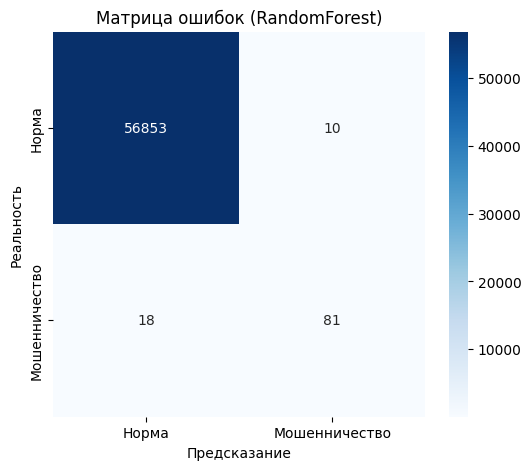

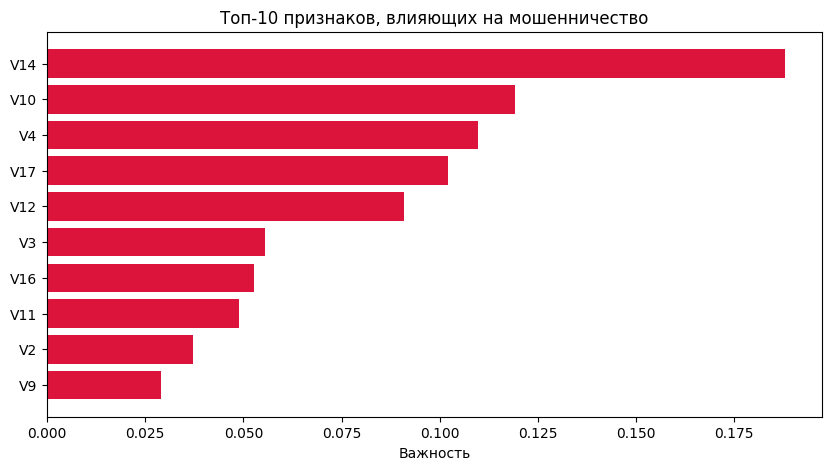

In [5]:
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Сохраняем модель (пригодится для портфолио)
joblib.dump(model, 'fraud_detector_model.pkl')
print("✅ Модель сохранена в файл fraud_detector_model.pkl")

# 2. Матрица ошибок в красивом виде
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Норма', 'Мошенничество'],
            yticklabels=['Норма', 'Мошенничество'])
plt.title('Матрица ошибок (RandomForest)')
plt.ylabel('Реальность')
plt.xlabel('Предсказание')
plt.show()

# 3. Топ-10 важных признаков
importances = model.feature_importances_
indices = np.argsort(importances)[::-1][:10]
feature_names = X.columns

plt.figure(figsize=(10,5))
plt.title('Топ-10 признаков, влияющих на мошенничество')
plt.barh(range(10), importances[indices][::-1], color='crimson')
plt.yticks(range(10), [feature_names[i] for i in indices[::-1]])
plt.xlabel('Важность')
plt.show()